# 🖼️ Intel Image Classification — CNN con PyTorch
## Reto proyecto 1 · Entrena una red neuronal convolucional para clasificar escenas naturales

---

Este notebook entrena una CNN desde cero para clasificar imágenes en **6 categorías de escenas naturales**  
usando el dataset *Intel Image Classification* (Kaggle, ~25 000 imágenes · 150×150 px).

| Paso | Descripción |
|------|-------------|
| 1️⃣ | Instalación e importación de librerías |
| 2️⃣ | Descarga del dataset (solo si no existe localmente) |
| 3️⃣ | Configuración de rutas y exploración de clases |
| 4️⃣ | Definición de 5 técnicas de aumento + transforms de evaluación |
| 5️⃣ | Carga con `ImageFolder` y `DataLoader` (batch_size=4, shuffle=True) |
| 6️⃣ | Visualización lado a lado: imágenes originales vs. aumentadas |
| 7️⃣ | Arquitectura CNN (3×Conv+BN+ReLU+Pool · 3 capas FC) |
| 8️⃣ | Entrenamiento 30 épocas · split val 15% · guardando el mejor modelo por `val_acc` |
| 9️⃣ | Curvas train/val de pérdida y precisión con marca del mejor epoch |
| 🔟 | Evaluación final: precisión global, F1-score por clase y matriz de confusión |

> **Dataset:** *Intel Image Classification* — 6 clases: `buildings · forest · glacier · mountain · sea · street`  
> **Objetivo:** clasificación multiclase (6 categorías, variable discreta)  
> **Entorno de desarrollo:** Realizado en Kaggle (permite uso de GPU gratuita · 30 h semanales)

## 1. Instalación e importación de librerías

In [29]:
%pip install torch torchvision matplotlib kagglehub scikit-learn --quiet

Note: you may need to restart the kernel to use updated packages.


In [30]:
import os
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset

from sklearn.metrics import confusion_matrix, f1_score, ConfusionMatrixDisplay

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo utilizado: {device}')

Dispositivo utilizado: cuda


## 2. Descarga del dataset (solo si no existe localmente)

In [31]:
import kagglehub

# ---------------------------------------------------------------------------
# CONFIGURACIÓN DE RUTA AL DATASET
# ---------------------------------------------------------------------------
# Ajusta LOCAL_DATASET_PATH si tienes el dataset descargado en tu máquina.
# Estructura esperada:
#   <LOCAL_DATASET_PATH>/
#     seg_train/seg_train/{buildings,forest,glacier,mountain,sea,street}/
#     seg_test/seg_test/{buildings,forest,glacier,mountain,sea,street}/
#
# Si la variable está vacía (''), el notebook descarga automáticamente
# el dataset desde Kaggle mediante kagglehub (requiere credenciales Kaggle).
# ---------------------------------------------------------------------------
LOCAL_DATASET_PATH = ''   # ← pon aquí tu ruta local, p. ej. '/datos/intel-images'

local_path = LOCAL_DATASET_PATH or './images'

if LOCAL_DATASET_PATH:
    # Ruta local explícita: no se necesita kagglehub ni conexión a internet
    dataset_path = LOCAL_DATASET_PATH
    print(f'Usando dataset local en: {dataset_path}')
elif os.path.exists(local_path) and len(os.listdir(local_path)) > 0:
    dataset_path = local_path
    print(f'Dataset encontrado localmente en: {dataset_path}')
else:
    print('Descargando dataset desde Kaggle...')
    dataset_path = kagglehub.dataset_download('puneet6060/intel-image-classification')
    print(f'Path to dataset files: {dataset_path}')

print('\nEstructura del dataset:')
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    if level > 2:
        continue
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')


Descargando dataset desde Kaggle...
Path to dataset files: /kaggle/input/datasets/puneet6060/intel-image-classification

Estructura del dataset:
intel-image-classification/
  seg_train/
    seg_train/
  seg_pred/
    seg_pred/
  seg_test/
    seg_test/


## 3. Configuración de rutas del dataset

In [32]:
train_dir = test_dir = None

for root, dirs, files in os.walk(dataset_path):
    for d in dirs:
        full = os.path.join(root, d)
        subdirs = [x for x in os.listdir(full) if os.path.isdir(os.path.join(full, x))]
        if 'seg_train' in d and 'pred' not in d and len(subdirs) >= 6:
            train_dir = full
        elif 'seg_test' in d and 'pred' not in d and len(subdirs) >= 6:
            test_dir = full

# Fallback para estructura seg_train/seg_train
if train_dir is None:
    c = os.path.join(dataset_path, 'seg_train', 'seg_train')
    if os.path.exists(c): train_dir = c
if test_dir is None:
    c = os.path.join(dataset_path, 'seg_test', 'seg_test')
    if os.path.exists(c): test_dir = c

print(f'Carpeta de entrenamiento : {train_dir}')
print(f'Carpeta de evaluación    : {test_dir}')
print(f'Clases detectadas        : {sorted(os.listdir(train_dir))}')

Carpeta de entrenamiento : /kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train
Carpeta de evaluación    : /kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test
Clases detectadas        : ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## 4. Transformaciones y Aumento de Imágenes

Se aplican **5 técnicas de aumento** al conjunto de entrenamiento siguiendo el orden canónico:
primero las transformaciones espaciales de gran escala (`RandomResizedCrop`), luego las
geométricas finas (`Flip`, `Rotation`) y finalmente las fotométricas (`ColorJitter`, `Grayscale`).

| # | Transformación | Efecto |
|---|---------------|--------|
| 1 | `RandomResizedCrop` | Recorte y redimensión aleatoria (escala espacial primero) |
| 2 | `RandomHorizontalFlip` | Espejado horizontal aleatorio |
| 3 | `RandomRotation(20)` | Rotación aleatoria ±20° |
| 4 | `ColorJitter` | Variación de brillo, contraste y saturación |
| 5 | `RandomGrayscale` | Conversión parcial a escala de grises |

In [33]:
# Transformaciones CON aumento (entrenamiento)
# Orden canónico: escala espacial → geometría fina → fotometría → tensor
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(150, scale=(0.7, 1.0)),  # Técnica 1: escala espacial primero
    transforms.RandomHorizontalFlip(p=0.5),               # Técnica 2: geometría fina
    transforms.RandomRotation(degrees=20),                # Técnica 3: geometría fina
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),  # Técnica 4: fotometría
    transforms.RandomGrayscale(p=0.1),                    # Técnica 5: fotometría
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Transformaciones SIN aumento (evaluación)
test_transforms = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Solo Resize+ToTensor para mostrar originales (sin normalización)
raw_transforms = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor()
])

print('Transformaciones definidas correctamente.')

Transformaciones definidas correctamente.


## 5. Carga del Dataset con DataLoader

In [34]:
BATCH_SIZE = 4

# Dataset CON aumento (entrenamiento)
train_dataset = ImageFolder(root=train_dir, transform=train_transforms)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

# Dataset SIN aumento (evaluación)
test_dataset = ImageFolder(root=test_dir, transform=test_transforms)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Dataset en crudo para visualización lado a lado
raw_dataset = ImageFolder(root=train_dir, transform=raw_transforms)

class_names = train_dataset.classes
num_classes  = len(class_names)

print(f'Clases ({num_classes})          : {class_names}')
print(f'Imágenes de entrenamiento : {len(train_dataset)}')
print(f'Imágenes de evaluación    : {len(test_dataset)}')
print(f'Lotes de entrenamiento    : {len(train_loader)}')

Clases (6)          : ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Imágenes de entrenamiento : 14034
Imágenes de evaluación    : 3000
Lotes de entrenamiento    : 3509


## 6. Visualización lado a lado: imágenes originales vs. aumentadas

Se cargan las **mismas 4 imágenes** con y sin aumento para comparar directamente
el efecto de cada transformación sobre el mismo contenido visual.

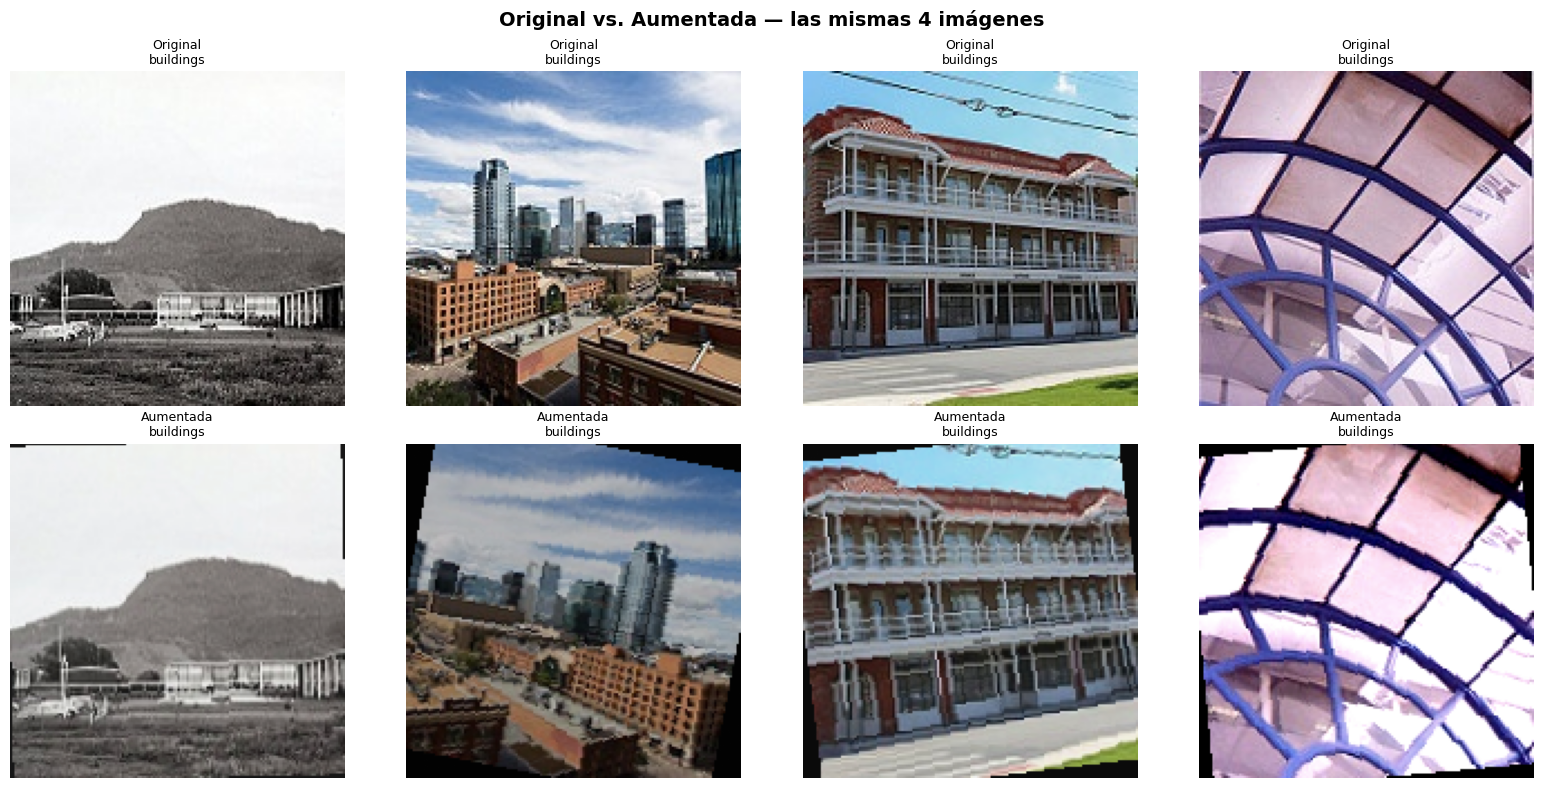

In [35]:
def denormalize(tensor):
    """Desnormaliza un tensor ImageNet para visualizarlo."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

# Mismos 4 índices para ambas versiones
fixed_indices = [0, 1, 2, 3]
raw_loader_vis = DataLoader(Subset(raw_dataset,   fixed_indices), batch_size=4, shuffle=False)
aug_loader_vis = DataLoader(Subset(train_dataset, fixed_indices), batch_size=4, shuffle=False)

raw_imgs, raw_labels = next(iter(raw_loader_vis))
aug_imgs, _          = next(iter(aug_loader_vis))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Original vs. Aumentada — las mismas 4 imágenes', fontsize=14, fontweight='bold')

for i in range(4):
    orig = raw_imgs[i].permute(1, 2, 0).numpy()
    axes[0, i].imshow(orig)
    axes[0, i].set_title(f'Original\n{class_names[raw_labels[i]]}', fontsize=9)
    axes[0, i].axis('off')

    aug = denormalize(aug_imgs[i]).permute(1, 2, 0).numpy()
    axes[1, i].imshow(aug)
    axes[1, i].set_title(f'Aumentada\n{class_names[raw_labels[i]]}', fontsize=9)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('ORIGINAL',  fontsize=11, fontweight='bold', rotation=90, labelpad=10)
axes[1, 0].set_ylabel('AUMENTADA', fontsize=11, fontweight='bold', rotation=90, labelpad=10)
plt.tight_layout()
plt.show()

## 7. Definición de la CNN

Arquitectura con **BatchNorm** en cada bloque convolucional y **Dropout espacial** (`Dropout2d`)
tras los dos últimos bloques conv para regularizar sin coste de parámetros adicional:

```
Input (3, 150, 150)
  └─ Conv1 (32) + BN + ReLU + MaxPool              →  (32, 75, 75)
  └─ Conv2 (64) + BN + ReLU + MaxPool + Dropout2d  →  (64, 37, 37)
  └─ Conv3 (128) + BN + ReLU + MaxPool + Dropout2d →  (128, 18, 18)
  └─ Flatten  →  41 472
  └─ FC1 (512) + ReLU + Dropout(0.5)
  └─ FC2 (128) + ReLU
  └─ FC3 (6)   →  logits
```

In [36]:
# ---------------------------------------------------------------------------
# Función auxiliar: calcula las dimensiones espaciales tras la pila conv
# ---------------------------------------------------------------------------
# Cambia INPUT_SIZE para probar otras resoluciones de entrada (p. ej. 224);
# las dimensiones intermedias y el tamaño del flatten se recalculan solos.
# ---------------------------------------------------------------------------

def calc_conv_output(h, w, *, num_pools=3, kernel=3, padding=1, pool_stride=2):
    """
    Calcula la altura y anchura del mapa de características tras `num_pools`
    bloques Conv(kernel, padding) + MaxPool(pool_stride).

    Parámetros
    ----------
    h, w         : dimensiones espaciales de entrada
    num_pools    : número de bloques conv+pool (por defecto 3)
    kernel       : tamaño del kernel convolucional (por defecto 3)
    padding      : relleno (por defecto 1 → sin reducción en la conv)
    pool_stride  : stride del MaxPool2d (por defecto 2)

    Devuelve
    --------
    (h_out, w_out) — dimensiones del mapa de salida (usando floor)
    """
    import math
    for _ in range(num_pools):
        # La Conv2d con kernel=3, padding=1 no cambia h×w
        h = math.floor((h - pool_stride) / pool_stride + 1)  # MaxPool
        w = math.floor((w - pool_stride) / pool_stride + 1)
    return h, w


INPUT_SIZE     = 150          # ← cámbialo aquí si ajustas la resolución de entrada
LAST_CHANNELS  = 128          # canales del último bloque conv

h_out, w_out   = calc_conv_output(INPUT_SIZE, INPUT_SIZE)
flatten_size   = LAST_CHANNELS * h_out * w_out

print(f'Entrada              : {INPUT_SIZE}×{INPUT_SIZE}')
print(f'Tras conv1 + pool    : {INPUT_SIZE//2}×{INPUT_SIZE//2}')
print(f'Tras conv2 + pool    : {INPUT_SIZE//2//2}×{INPUT_SIZE//2//2}')
print(f'Tras conv3 + pool    : {h_out}×{w_out}')
print(f'Flatten → FC entrada : {LAST_CHANNELS} × {h_out} × {w_out} = {flatten_size:,}')


Entrada              : 150×150
Tras conv1 + pool    : 75×75
Tras conv2 + pool    : 37×37
Tras conv3 + pool    : 18×18
Flatten → FC entrada : 128 × 18 × 18 = 41,472


In [37]:
class IntelCNN(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()

        # Bloque convolucional 1: (3,150,150) → (32,75,75)
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Bloque convolucional 2: (32,75,75) → (64,37,37)
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(p=0.15)   # Regularización espacial en mapa de características
        )

        # Bloque convolucional 3: (64,37,37) → (128,18,18)
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(p=0.15)   # Regularización espacial — mayor presión en capa más profunda
        )

        # Clasificador fully connected
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flatten_size, 512),  # dimensión derivada automáticamente por calc_conv_output()
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 128),          # FC2 extra
            nn.ReLU(),
            nn.Linear(128, num_classes)   # FC salida
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        return self.classifier(x)


model = IntelCNN(num_classes=num_classes).to(device)
print(model)
print(f'\nParámetros totales: {sum(p.numel() for p in model.parameters()):,}')

IntelCNN(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.15, inplace=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.15, inplace=False)
  )
  (classifier): Sequential(
    

## 8. Entrenamiento — 30 épocas · mejor modelo según precisión de **validación**

In [38]:
from torch.utils.data import random_split

criterion  = nn.CrossEntropyLoss()
optimizer  = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
NUM_EPOCHS = 30

# --- Split de validación (15 % del train) ---
# Usamos el dataset CON aumento para train y SIN aumento para val
val_size   = int(0.15 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_split, val_split_aug = random_split(
    train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Para val usamos los mismos índices pero con test_transforms (sin aumento)
val_dataset_clean = ImageFolder(root=train_dir, transform=test_transforms)
val_split_clean   = Subset(val_dataset_clean, val_split_aug.indices)

train_loader_split = DataLoader(train_split,      batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader         = DataLoader(val_split_clean,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Tamaño train efectivo : {train_size}')
print(f'Tamaño validación     : {val_size}')
print(f'Criterio:    CrossEntropyLoss')
print(f'Optimizador: Adam (lr=0.0001, weight_decay=1e-4)')
print(f'Épocas:      {NUM_EPOCHS}')

train_losses     = []
train_accuracies = []
val_losses       = []
val_accuracies   = []
best_val_acc     = 0.0
best_epoch       = 0

for epoch in range(1, NUM_EPOCHS + 1):
    # ---- Fase de entrenamiento ----
    model.train()
    running_loss = correct = total = 0

    for images, labels in train_loader_split:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds      = torch.max(outputs, 1)
        total        += labels.size(0)
        correct      += (preds == labels).sum().item()

    epoch_loss = running_loss / len(train_loader_split)
    epoch_acc  = 100.0 * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    # ---- Fase de validación (sin gradientes) ----
    model.eval()
    v_loss = v_correct = v_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            v_loss += criterion(outputs, labels).item()
            _, preds = torch.max(outputs, 1)
            v_total   += labels.size(0)
            v_correct += (preds == labels).sum().item()

    val_epoch_loss = v_loss / len(val_loader)
    val_epoch_acc  = 100.0 * v_correct / v_total
    val_losses.append(val_epoch_loss)
    val_accuracies.append(val_epoch_acc)

    # Guardar el mejor modelo según precisión de VALIDACIÓN (criterio más robusto)
    if val_epoch_acc > best_val_acc:
        best_val_acc = val_epoch_acc
        best_epoch   = epoch
        torch.save(copy.deepcopy(model.state_dict()), 'best_model.pth')

    marker = ' ⭐ mejor val' if epoch == best_epoch else ''
    print(f'Época [{epoch:2d}/{NUM_EPOCHS}]  '
          f'Train — Pérd: {epoch_loss:.4f} Acc: {epoch_acc:.2f}%  '
          f'Val — Pérd: {val_epoch_loss:.4f} Acc: {val_epoch_acc:.2f}%{marker}')

print(f'\n✅ Entrenamiento completado. Mejor época: {best_epoch} (val acc: {best_val_acc:.2f}%)')
print('   Pesos guardados en best_model.pth')

Tamaño train efectivo : 11929
Tamaño validación     : 2105
Criterio:    CrossEntropyLoss
Optimizador: Adam (lr=0.0001, weight_decay=1e-4)
Épocas:      30
Época [ 1/30]  Train — Pérd: 1.3064 Acc: 47.71%  Val — Pérd: 1.0863 Acc: 58.76% ⭐ mejor val
Época [ 2/30]  Train — Pérd: 1.1167 Acc: 56.32%  Val — Pérd: 0.8268 Acc: 69.60% ⭐ mejor val
Época [ 3/30]  Train — Pérd: 1.0195 Acc: 60.67%  Val — Pérd: 0.9390 Acc: 67.03%
Época [ 4/30]  Train — Pérd: 0.9864 Acc: 62.65%  Val — Pérd: 0.7700 Acc: 72.68% ⭐ mejor val
Época [ 5/30]  Train — Pérd: 0.9251 Acc: 65.57%  Val — Pérd: 0.6999 Acc: 76.15% ⭐ mejor val
Época [ 6/30]  Train — Pérd: 0.8934 Acc: 66.81%  Val — Pérd: 0.6613 Acc: 75.25%
Época [ 7/30]  Train — Pérd: 0.8575 Acc: 68.07%  Val — Pérd: 0.6597 Acc: 76.44% ⭐ mejor val
Época [ 8/30]  Train — Pérd: 0.8245 Acc: 69.60%  Val — Pérd: 0.7538 Acc: 70.21%
Época [ 9/30]  Train — Pérd: 0.8102 Acc: 70.11%  Val — Pérd: 0.5825 Acc: 79.19% ⭐ mejor val
Época [10/30]  Train — Pérd: 0.7824 Acc: 71.53%  Val —

## 9. Curvas de entrenamiento con marca del mejor epoch

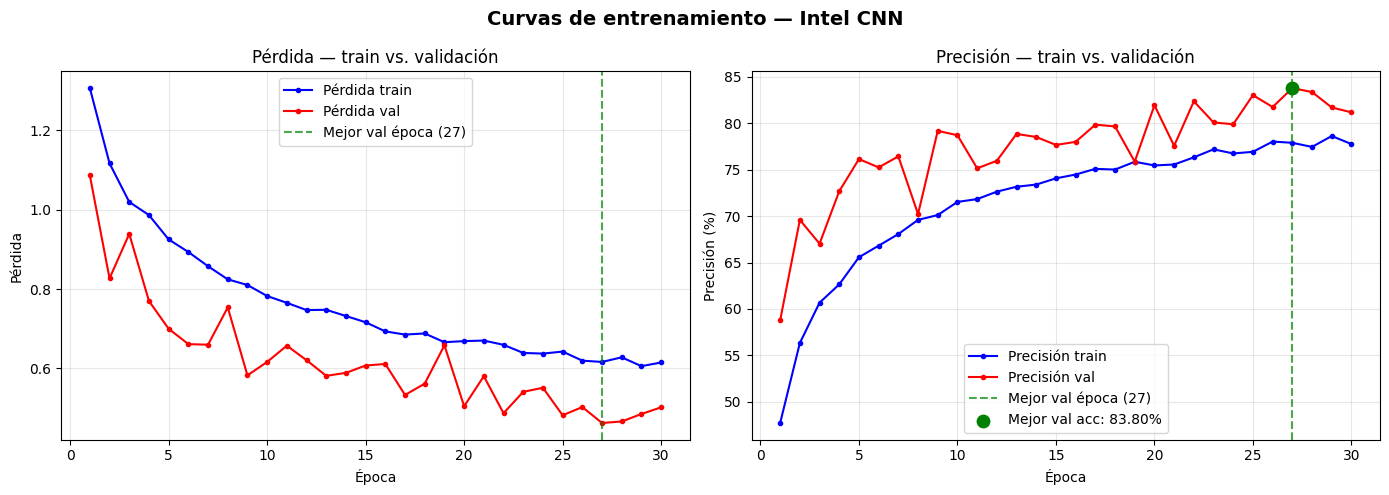

In [39]:
epochs_range = list(range(1, NUM_EPOCHS + 1))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pérdida: train vs val
ax1.plot(epochs_range, train_losses, 'b-o', markersize=3, label='Pérdida train')
ax1.plot(epochs_range, val_losses,   'r-o', markersize=3, label='Pérdida val')
ax1.axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Mejor val época ({best_epoch})')
ax1.set_title('Pérdida — train vs. validación')
ax1.set_xlabel('Época'); ax1.set_ylabel('Pérdida')
ax1.legend(); ax1.grid(True, alpha=0.3)

# Precisión: train vs val
ax2.plot(epochs_range, train_accuracies, 'b-o', markersize=3, label='Precisión train')
ax2.plot(epochs_range, val_accuracies,   'r-o', markersize=3, label='Precisión val')
ax2.axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Mejor val época ({best_epoch})')
ax2.scatter([best_epoch], [best_val_acc], color='green', zorder=5, s=80,
            label=f'Mejor val acc: {best_val_acc:.2f}%')
ax2.set_title('Precisión — train vs. validación')
ax2.set_xlabel('Época'); ax2.set_ylabel('Precisión (%)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Curvas de entrenamiento — Intel CNN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Evaluación final con el mejor modelo (imágenes SIN aumento)

La función `evaluate()` es reutilizable: acepta cualquier modelo y loader
y devuelve un diccionario con todas las métricas, facilitando futuros experimentos.

In [40]:
def evaluate(model, loader, criterion, device):
    """
    Evalúa `model` sobre `loader` y devuelve un diccionario con:
      loss        — pérdida media
      accuracy    — precisión global (%)
      f1_macro    — F1-score macro
      f1_per_class— F1 por clase (array)
      preds       — predicciones (np.array)
      labels      — etiquetas reales (np.array)
    """
    model.eval()
    total_loss = correct = total = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            total_loss    += criterion(outputs, labels).item()
            _, preds       = torch.max(outputs, 1)
            total         += labels.size(0)
            correct       += (preds == labels).sum().item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    return {
        'loss':          total_loss / len(loader),
        'accuracy':      100.0 * correct / total,
        'f1_macro':      f1_score(all_labels, all_preds, average='macro'),
        'f1_per_class':  f1_score(all_labels, all_preds, average=None),
        'preds':         all_preds,
        'labels':        all_labels,
    }


# Cargar los pesos del mejor modelo (seleccionado por val_acc)
model.load_state_dict(torch.load('best_model.pth', map_location=device))

results    = evaluate(model, test_loader, criterion, device)
final_loss = results['loss']
final_acc  = results['accuracy']
all_preds  = results['preds']
all_labels = results['labels']

print('=' * 48)
print('        RESULTADOS DE EVALUACIÓN FINAL')
print('=' * 48)
print(f'  Pérdida en test   : {final_loss:.4f}')
print(f'  Precisión en test : {final_acc:.2f}%')
print(f'  F1-score macro    : {results["f1_macro"]:.4f}')
print('=' * 48)

        RESULTADOS DE EVALUACIÓN FINAL
  Pérdida en test   : 0.4822
  Precisión en test : 83.83%
  F1-score macro    : 0.8379


### 10.1 Precisión y F1-score por clase

Clase           Precisión   F1-score
--------------------------------------
buildings          80.55%     0.8139
forest             98.31%     0.9405
glacier            66.37%     0.7630
mountain           86.86%     0.8114
sea                84.90%     0.8432
street             88.02%     0.8555
--------------------------------------
PROMEDIO           83.83%     0.8379


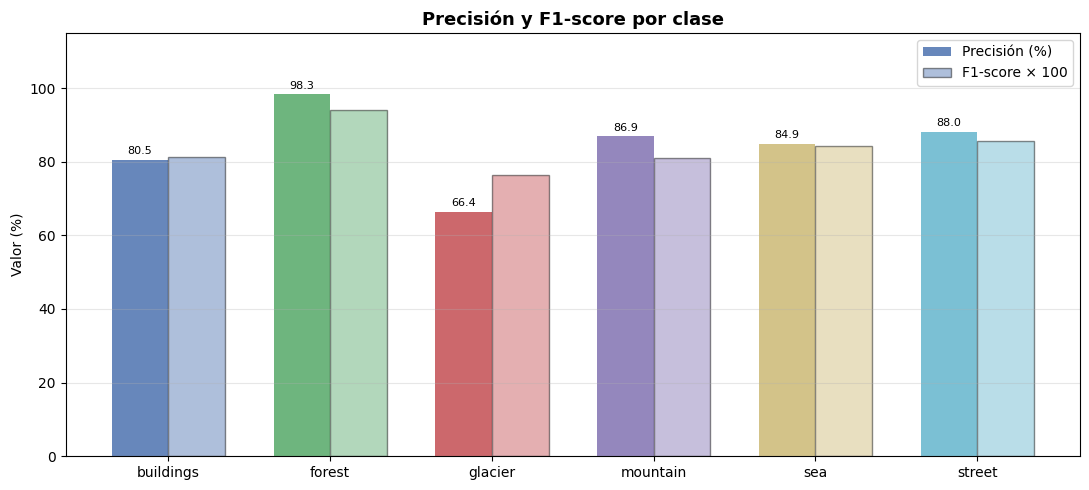

In [41]:
f1_scores = results['f1_per_class']
accs      = []

print(f'{"Clase":<14} {"Precisión":>10} {"F1-score":>10}')
print('-' * 38)
for i, cls in enumerate(class_names):
    mask    = all_labels == i
    cls_acc = 100.0 * (all_preds[mask] == all_labels[mask]).sum() / mask.sum()
    accs.append(cls_acc)
    print(f'{cls:<14} {cls_acc:>9.2f}% {f1_scores[i]:>10.4f}')

print('-' * 38)
print(f'{"PROMEDIO":<14} {final_acc:>9.2f}% {f1_score(all_labels, all_preds, average="macro"):>10.4f}')

# Gráfico de barras doble
x     = np.arange(num_classes)
width = 0.35
colors = ['#4C72B0','#55A868','#C44E52','#8172B2','#CCB974','#64B5CD']

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, accs,             width, label='Precisión (%)',   color=colors, alpha=0.85)
bars2 = ax.bar(x + width/2, f1_scores * 100,  width, label='F1-score × 100', color=colors, alpha=0.45, edgecolor='k')
ax.set_xticks(x); ax.set_xticklabels(class_names)
ax.set_ylim(0, 115)
ax.set_ylabel('Valor (%)')
ax.set_title('Precisión y F1-score por clase', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar, v in zip(bars1, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{v:.1f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

### 10.2 Matriz de confusión

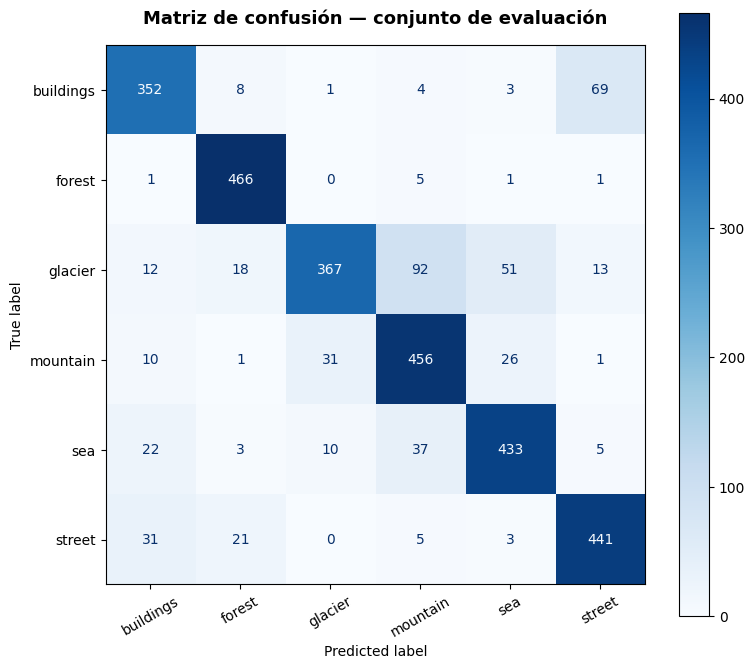

In [42]:
cm   = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=30)
ax.set_title('Matriz de confusión — conjunto de evaluación',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 11. Resumen final del proyecto

In [43]:
print('=' * 58)
print('                 RESUMEN DEL PROYECTO')
print('=' * 58)
print(f'  Dataset             : Intel Image Classification')
print(f'  Clases ({num_classes})           : {", ".join(class_names)}')
print(f'  Imágenes train      : {train_size}  |  Val: {val_size}')
print(f'  Imágenes test       : {len(test_dataset)}')
print(f'  Épocas entrenadas   : {NUM_EPOCHS}')
print(f'  Mejor época (val)   : {best_epoch} (val acc: {best_val_acc:.2f}%)')
print(f'  Capas conv          : 3 × (Conv2d + BN + ReLU + MaxPool + Dropout2d)')
print(f'  Capas FC            : FC(512) + Dropout(0.5) + FC(128) + FC(6)')
print(f'  Orden aumento       : RandomResizedCrop → Flip → Rotation → ColorJitter → Grayscale')
print(f'  Optimizador         : Adam (lr=0.0001, weight_decay=1e-4)')
print(f'  Pérdida final train : {train_losses[-1]:.4f}')
print(f'  Pérdida final val   : {val_losses[-1]:.4f}')
print(f'  Pérdida final test  : {final_loss:.4f}')
print(f'  Precisión test      : {final_acc:.2f}%')
print(f'  F1-score macro      : {results["f1_macro"]:.4f}')
print(f'  Modelo guardado en  : best_model.pth')
print('=' * 58)

                 RESUMEN DEL PROYECTO
  Dataset             : Intel Image Classification
  Clases (6)           : buildings, forest, glacier, mountain, sea, street
  Imágenes train      : 11929  |  Val: 2105
  Imágenes test       : 3000
  Épocas entrenadas   : 30
  Mejor época (val)   : 27 (val acc: 83.80%)
  Capas conv          : 3 × (Conv2d + BN + ReLU + MaxPool + Dropout2d)
  Capas FC            : FC(512) + Dropout(0.5) + FC(128) + FC(6)
  Orden aumento       : RandomResizedCrop → Flip → Rotation → ColorJitter → Grayscale
  Optimizador         : Adam (lr=0.0001, weight_decay=1e-4)
  Pérdida final train : 0.6149
  Pérdida final val   : 0.5020
  Pérdida final test  : 0.4822
  Precisión test      : 83.83%
  F1-score macro      : 0.8379
  Modelo guardado en  : best_model.pth
